<a href="https://colab.research.google.com/github/gowtham7019744655/student/blob/main/Fake_News_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fake News Prediction

NOTE: If you have limitation on compute power, load the dataset form kaggle to google colab through Kaggle API

In [17]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

1. Setup

In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [19]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "WELFake_Dataset.csv"          # update path for a different dataset
TARGET_COL = "label" # target column name

2. Load Data & Sample

In [20]:
import csv
csv.field_size_limit(1000000)
# Using quoting=csv.QUOTE_NONE to prevent unclosed quotes from cutting off the file
data = pd.read_csv(CSV_PATH, engine='python', on_bad_lines='skip', quoting=csv.QUOTE_NONE)

In [21]:
data.shape

(11319, 4)

In [22]:
data.head()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Unnamed: 0,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],"""No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to turn the tide and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called Sunshine. She has a radio blog show hosted from Texas called",Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show,callers clearly call for lynching and killing of white people.A 2:39 minute clip from the radio show can be heard here. It was provided to Breitbart Texas by someone who would like to be referred to as Hannibal. He has already received death threats as a result of interrupting #FYF911 conference calls.An unidentified black man said when those mother f**kers are by themselves,that s when when we should start f***ing them up. Like they do us,when a bunch of them ni**ers takin one of us out,that s how we should roll up. He said,Cause we already roll up in gangs anyway. There should be six or seven black mother f**ckers,see that white person,and then lynch their ass. Let s turn the tables. They conspired that if cops started losing people,then there will be a state of emergency. He speculated that one of two things would happen,a big-ass [R s?????] war,or ni**ers,they are going to start backin up. We are already getting killed out here so what the f**k we got to lose? Sunshine could be heard saying,Yep,that s true. That s so f**king true. He said,We need to turn the tables on them. Our kids are getting shot out here. Somebody needs to become a sacrifice on their side.He said,Everybody ain t down for that s**t,or whatever,but like I say,everybody has a different position of war. He continued,Because they don t give a f**k anyway. He said again,We might as well utilized them for that s**t and turn the tables on these n**ers. He said,that way we can start lookin like we ain t havin that many casualties,and there can be more causalities on their side instead of ours. They are out their killing black people,black lives don t matter,that s what those mother f**kers so we got to make it matter to them. Find a mother f**ker that is alone. Snap his ass,and then f***in hang him from a damn tree. Take a picture of it and then send it to the mother f**kers. We just need one example,and then people will start watchin . This will turn the tables on s**t,he said. He said this will start a trickle-down effect. He said that when one white person is hung and then they are just flat-hanging,that will start the trickle-down effect. He continued,Black people are good at starting trends. He said that was how to get the upper-hand. Another black man spoke up saying they needed to kill cops that are killing us. The first black male said,That will be the best method right there. Breitbart Texas previously reported how Sunshine was upset when racist white people infiltrated and disrupted one of her conference calls. She subsequently released the phone number of one of the infiltrators. The veteran immediately started receiving threatening calls.One of the #F***YoFlag movement supporters allegedly told a veteran who infiltrated their publicly posted conference call,We are going to rape and gut your pregnant wife,and your f***ing piece of sh*t unborn creature will be hung from a tree. Breitbart Texas previously encountered Sunshine at a Sandra Bland protest at the Waller County Ja

data.head()

In [23]:
data = data.drop(columns=["Unnamed: 0"])

In [24]:
data.head()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],"""No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to turn the tide and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called Sunshine. She has a radio blog show hosted from Texas called",Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show,callers clearly call for lynching and killing of white people.A 2:39 minute clip from the radio show can be heard here. It was provided to Breitbart Texas by someone who would like to be referred to as Hannibal. He has already received death threats as a result of interrupting #FYF911 conference calls.An unidentified black man said when those mother f**kers are by themselves,that s when when we should start f***ing them up. Like they do us,when a bunch of them ni**ers takin one of us out,that s how we should roll up. He said,Cause we already roll up in gangs anyway. There should be six or seven black mother f**ckers,see that white person,and then lynch their ass. Let s turn the tables. They conspired that if cops started losing people,then there will be a state of emergency. He speculated that one of two things would happen,a big-ass [R s?????] war,or ni**ers,they are going to start backin up. We are already getting killed out here so what the f**k we got to lose? Sunshine could be heard saying,Yep,that s true. That s so f**king true. He said,We need to turn the tables on them. Our kids are getting shot out here. Somebody needs to become a sacrifice on their side.He said,Everybody ain t down for that s**t,or whatever,but like I say,everybody has a different position of war. He continued,Because they don t give a f**k anyway. He said again,We might as well utilized them for that s**t and turn the tables on these n**ers. He said,that way we can start lookin like we ain t havin that many casualties,and there can be more causalities on their side instead of ours. They are out their killing black people,black lives don t matter,that s what those mother f**kers so we got to make it matter to them. Find a mother f**ker that is alone. Snap his ass,and then f***in hang him from a damn tree. Take a picture of it and then send it to the mother f**kers. We just need one example,and then people will start watchin . This will turn the tables on s**t,he said. He said this will start a trickle-down effect. He said that when one white person is hung and then they are just flat-hanging,that will start the trickle-down effect. He continued,Black people are good at starting trends. He said that was how to get the upper-hand. Another black man spoke up saying they needed to kill cops that are killing us. The first black male said,That will be the best method right there. Breitbart Texas previously reported how Sunshine was upset when racist white people infiltrated and disrupted one of her conference calls. She subsequently released the phone number of one of the infiltrators. The veteran immediately started receiving threatening calls.One of the #F***YoFlag movement supporters allegedly told a veteran who infiltrated their publicly posted conference call,We are going to rape and gut your pregnant wife,and your f***ing piece of sh*t unborn creature will be hung from a tree. Breitbart Texas previously encountered Sunshine at a Sandra Bland protest at the Waller County Jail in Texas

Get a Sample for faster processing and training

In [25]:
# target distribution
print(data["label"].value_counts())
print("-"*40)
print(data["label"].value_counts(normalize=True)*100)

label
1.000    7
0.000    5
Name: count, dtype: int64
----------------------------------------
label
1.000   58.333
0.000   41.667
Name: proportion, dtype: float64


In [29]:
n_samples_desired = 10000 # Original desired number of samples

# separate data
df_fake = data[data["label"] == 0]
df_real = data[data["label"] == 1]
n_samples = min(len(df_fake), len(df_real))

# Check if any class is empty after filtering
if n_samples == 0:
    print("Warning: One or both classes are empty after filtering for label. Cannot perform sampling.")
    df = pd.DataFrame(columns=data.columns) # Create an empty DataFrame to prevent further errors
else:
    # sample
    df_fake_sample = df_fake.sample(n_samples, random_state=RANDOM_STATE)
    df_real_sample = df_real.sample(n_samples, random_state=RANDOM_STATE)

    # Combine and shuffle
    df = (
        pd.concat([df_fake_sample, df_real_sample])
          .sample(frac=1, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )

In [30]:
print(df["label"].value_counts())
print("-"*40)
print(df["label"].value_counts(normalize=True)*100)

label
1.000    5
0.000    5
Name: count, dtype: int64
----------------------------------------
label
1.000   50.000
0.000   50.000
Name: proportion, dtype: float64


3. Exploratory Data Analysis (EDA) & Data Preprocessing

In [31]:
# dataframe columns
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [32]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   10 non-null     object 
 1   text    10 non-null     object 
 2   label   10 non-null     float64
dtypes: float64(1), object(2)
memory usage: 372.0+ bytes


In [33]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [34]:
# can be dropped as less number of rows has missing values compared to the dataset size
df = df.dropna()

In [35]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [36]:
# target distribution
print(df["label"].value_counts())
print("="*40)
print(df["label"].value_counts(normalize=True)*100)

label
1.000    5
0.000    5
Name: count, dtype: int64
label
1.000   50.000
0.000   50.000
Name: proportion, dtype: float64


Text Cleaning

In [37]:
def clean_text(s: str) -> str:
    """
    Simple text cleaning:
    - lowercasing
    - remove URLs
    - remove HTML tags
    - keep letters/numbers and basic punctuation
    - normalize spaces
    """
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)          # URLs
    s = re.sub(r"<.*?>", " ", s)                    # HTML tags
    s = re.sub(r"[^a-z0-9\s\.\,\!\?\-\']", " ", s)   # keep basic chars
    s = re.sub(r"\s+", " ", s).strip()               # normalize spaces
    return s

In [38]:
# example
a = "ABCabc  123*"
b = "zyxABC 999"

c = a + " " + b
print(c)

d = clean_text(c)

print(d)

ABCabc  123* zyxABC 999
abcabc 123 zyxabc 999


In [39]:
# combine title and text & apply clean_text function
df["content"] = (df["title"] + " " + df["text"]).apply(clean_text)

In [40]:
df.head()

,title,text,label,content
0,Ambassador Janet Sanderson wrote that represe...,charg d affaires Thomas Tighe told the diplo...,1.000,ambassador janet sanderson wrote that represen...
1,but he’s going to be ready,” said Republican National Committee Chairman ...,0.000,but he s going to be ready said republican nat...
2,and a photo of a black man,wiping their naked butts with the American fl...,1.000,and a photo of a black man wiping their naked ...
3,defended Mrs. Clinton and derided Mr. Trump a...,Mr. Booker praised his Senate colleague. “Tim...,0.000,defended mrs. clinton and derided mr. trump as...
4,just maybe,they ll start demanding Republicans stop cate...,1.000,just maybe they ll start demanding republicans...


In [41]:
# adding additional columns for analysis
df["title_len_chars"] = df["title"].str.len()
df["text_len_chars"] = df["text"].str.len()
df["content_len_word"] = df["content"].str.split().apply(len)

In [42]:
df.head()

,title,text,label,content,title_len_chars,text_len_chars,content_len_word
0,Ambassador Janet Sanderson wrote that represe...,charg d affaires Thomas Tighe told the diplo...,1.000,ambassador janet sanderson wrote that represen...,646,149,122
1,but he’s going to be ready,” said Republican National Committee Chairman ...,0.000,but he s going to be ready said republican nat...,27,159,34
2,and a photo of a black man,wiping their naked butts with the American fl...,1.000,and a photo of a black man wiping their naked ...,27,82,19
3,defended Mrs. Clinton and derided Mr. Trump a...,Mr. Booker praised his Senate colleague. “Tim...,0.000,defended mrs. clinton and derided mr. trump as...,195,120,53
4,just maybe,they ll start demanding Republicans stop cate...,1.000,just maybe they ll start demanding republicans...,11,143,25


In [43]:
num_cols = ["title_len_chars", "text_len_chars", "content_len_word"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_chars,10.000,131.500,194.271,10.000,27.000,44.500,175.000,646.000
text_len_chars,10.000,118.400,53.654,17.000,96.250,110.500,147.500,218.000
content_len_word,10.000,39.700,33.300,4.000,22.250,29.500,48.250,122.000


Data Visuzlaization

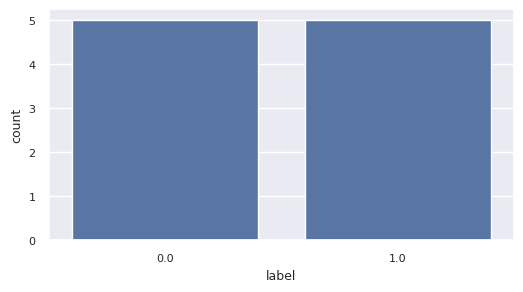

In [44]:
plt.figure(figsize=(6,3))
sns.countplot(x="label", data=df)
plt.show()

**NOTE: Almost Equal class distribution**

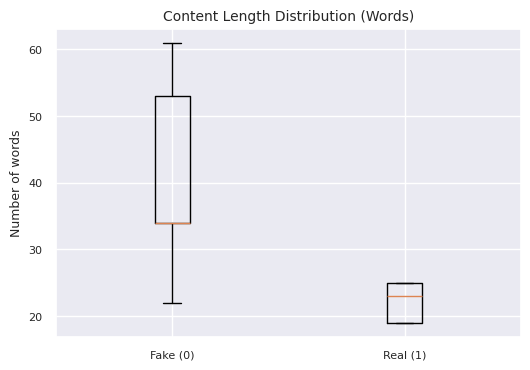

In [45]:
# text length distribution (words) - boxplot
fake_lens = df[df["label"] == 0]["content_len_word"].values
real_lens = df[df["label"] == 1]["content_len_word"].values

plt.figure(figsize=(6,4))
plt.boxplot(
    [fake_lens, real_lens],
    tick_labels=["Fake (0)", "Real (1)"],
    showfliers=False
)
plt.title("Content Length Distribution (Words)")
plt.ylabel("Number of words")
plt.show()

In [46]:
# separate features and target
X = df["content"]
y = df["label"]

In [47]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [48]:
print("\nTrain size:", len(X_train), "| Test size:", len(X_test))


Train size: 8 | Test size: 2


4. Vectorization & Model Training Pipeline

---

**What does TF-IDF mean?**

TF-IDF stands for:

Term Frequency – Inverse Document Frequency
- Term Frequency (TF): How often a word appears in a single document.
- Inverse Document Frequency (IDF): How rare that word is across all documents.

⸻

**How less important words get less importance**

Think of words like:
the, is, and, to

These words:
- Appear in almost every document
- Do not help distinguish fake vs real news

So TF-IDF does this:
- If a word appears many times in one document → its TF increases
- If the same word appears in almost all documents → its IDF becomes very small
- Final weight = TF × IDF

Result:
- Common words → low TF-IDF score
- Rare but meaningful words → high TF-IDF score

---

Simple Intuition:

TF-IDF rewards words that are frequent in a document but uncommon in the overall dataset. Words that appear everywhere are treated as less important.

In [49]:
model_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2),
            stop_words="english",
            min_df=2
        )),
        ("model", LogisticRegression())
    ]
)

NOTE: No scaling required

TF-IDF already produces normalized numerical features
Each feature represents a word importance score, not a raw magnitude

In [50]:
# train the pipeline
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression())])

5. Model Evaluation

In [51]:
y_pred_train = model_pipeline.predict(X_train)
y_proba_train = model_pipeline.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("\n--- Train Metrics ---")
print(f"Accuracy : {acc_train:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_train)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_train, digits=4))


--- Train Metrics ---
Accuracy : 1.0000

Confusion Matrix [ [TN FP], [FN TP] ]:
[[4 0]
 [0 4]]

Classification Report:
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000         4
         1.0     1.0000    1.0000    1.0000         4

    accuracy                         1.0000         8
   macro avg     1.0000    1.0000    1.0000         8
weighted avg     1.0000    1.0000    1.0000         8



In [52]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Test Metrics ---")
print(f"Accuracy : {acc:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


--- Test Metrics ---
Accuracy : 0.5000

Confusion Matrix [ [TN FP], [FN TP] ]:
[[0 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000         1
         1.0     0.5000    1.0000    0.6667         1

    accuracy                         0.5000         2
   macro avg     0.2500    0.5000    0.3333         2
weighted avg     0.2500    0.5000    0.3333         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


6. Build predictive system

In [53]:
def predict_news(title, text):
    combined = clean_text(f"{title} {text}")
    prediction = model_pipeline.predict([combined])
    print(prediction)
    if prediction[0] == 1:
        print("This is a Real News 🟢")
    else:
        print("This is a Fake News 🔴")


In [54]:
# Example prediction
example_title = "Breaking: Government announces new economic policy"
example_text = "The finance minister introduced a new policy today after discussions in parliament..."
prediction = predict_news(example_title, example_text)

[1.]
This is a Real News 🟢


What Next?

Try cross validation
model selection
hyperparam tuning